In [1]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import pickle
import time
from collections import OrderedDict

velocity = 1.0
num_epochs = 10000
nu = 0.01

In [2]:
def analytical_solution(t, x):
    u = 0.5 * (torch.sin(torch.pi * (x + t)) + torch.sin(torch.pi * (x - t)))
    v = 0.5 * torch.pi * (torch.cos(torch.pi * (x + t)) - torch.cos(torch.pi * (x - t)))
    return torch.cat([u, v], dim=1)

class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 2) 
        self.tanh = nn.Tanh()

    def forward(self, x, t=None):
        if t is not None:
            inputs = torch.cat([t, x], dim=1) 
        else:
            inputs = x
            
        out = self.linear1(inputs)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        out = self.tanh(out)
        out = self.output(out)
        return out

In [3]:
# 从sampling_PDE.py引入的DNN类
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class sampling_MMPDE():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        self.lb = torch.tensor(lb).float()
        self.ub = torch.tensor(ub).float()

        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float()
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float()
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        self.dnn = DNN(layers)

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, u, t, x):

        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]
        
        u_tt = torch.autograd.grad(
            u_t, t,
            grad_outputs=torch.ones_like(u_t),
            retain_graph=True,
            create_graph=True
        )[0]
        
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]

        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]
        
        w = (1 + (0.3 * u_xx) ** 2 + (0.4  * u_tt ** 2)) ** (1 / 2)
        
        return w

    def net_sample(self, t, x):
        xNew = self.dnn(torch.cat([t, x], dim=1))
        g0 = x - self.lb[1]
        g1 = x - self.ub[1]
        xNew = g0*g1*xNew + x
        return xNew

    def net_f(self, t, x):
        xNew = self.net_sample(t, x)

        xNew_t = torch.autograd.grad(
            xNew, t,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]

        xNew_x = torch.autograd.grad(
            xNew, x,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]
        
        xNew_xx = torch.autograd.grad(
            xNew_x, x,
            grad_outputs=torch.ones_like(xNew_x),
            retain_graph=True,
            create_graph=True
        )[0]

        u = self.fun(torch.cat([t, x], dim=1))
        
        G = self.monitor(u, t, x)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        E = G_x * xNew_x + G * xNew_xx
        f = xNew_t*self.nu*(G**2)*(xNew_x**2) + E

        return f

    def loss_func(self):
        # 计算损失函数
        f_pred = self.net_f(self.t_f, self.x_f)
        loss_f = torch.mean(f_pred ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        # 损失函数初始化
        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = 'EMMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = 'EMMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        # 训练过程
        print("开始MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("EMMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('EMMPDE_LBGFS 完成!')

        # 返回新的采样点
        new_x = self.net_sample(self.t_f, self.x_f)
        new_sample = torch.cat([self.t_f, new_x], dim=1)
        return new_sample

def create_simulation_function(model=None):
    # 如果没有提供模型，则使用解析解
    def simulation_function(xt):
        t, x = xt[:, 0:1], xt[:, 1:2]
        return 0.5 * (torch.sin(torch.pi * (x + t)) + torch.sin(torch.pi * (x - t)))
        
    return simulation_function

In [4]:
pinn_initial_epochs = 2000  # 初始PINN训练轮数
pinn_adaptive_epochs = 2000  # 每次自适应采样后的PINN训练轮数
num_iterations = 2  # 迭代次数
mmpde_training_epochs = 1000  # MMPDE训练轮数

adam_lr = 0.001
lbfgs_lr = 0.005

In [5]:
# 新增cell - 创建基于模型的模拟函数
def create_simulation_function_from_model(model):
    """基于当前PINN模型创建模拟函数"""
    def simulation_function(xt):
        model.eval()
        # 确保输入张量需要梯度（MMPDE需要计算梯度）
        if not xt.requires_grad:
            xt = xt.requires_grad_(True)
        
        outputs = model(xt)
        u = outputs[:, 0:1]  # 只取u分量用于monitor
        return u
    return simulation_function

def generate_uniform_collocation_points_1d(n_points=1000):
    """生成一维均匀配点"""
    n_per_dim = int(np.sqrt(n_points))
    
    t_uniform = torch.linspace(0, 1, n_per_dim)
    x_uniform = torch.linspace(-1, 1, n_per_dim)
    
    T_grid, X_grid = torch.meshgrid(t_uniform, x_uniform, indexing='ij')
    
    t_coll = T_grid.reshape(-1, 1)
    x_coll = X_grid.reshape(-1, 1)
    
    t_coll.requires_grad_(True)
    x_coll.requires_grad_(True)
    
    print(f"生成等距配点网格: {n_per_dim}×{n_per_dim} = {t_coll.shape[0]}个点")
    
    return t_coll, x_coll

def generate_initial_training_data_1d():
    """生成初始训练数据"""
    # 生成配点
    t_colloc, x_colloc = generate_uniform_collocation_points_1d(1000)
    x_colloc_combined = torch.cat([t_colloc, x_colloc], dim=1)
    
    # 边界条件
    N_bc = 100
    t_bc = torch.rand(N_bc, 1)
    x_bc_left = -torch.ones(N_bc//2, 1) 
    x_bc_right = torch.ones(N_bc//2, 1)
    x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
    t_bc_split = torch.split(t_bc, N_bc//2)
    x_bc_left_combined = torch.cat([t_bc_split[0], x_bc_left], dim=1)
    x_bc_right_combined = torch.cat([t_bc_split[1], x_bc_right], dim=1)
    x_bc_combined = torch.cat([x_bc_left_combined, x_bc_right_combined], dim=0)
    x_bc_combined.requires_grad_(True)
    
    # 初始条件
    N_ic = 100
    x_ic = torch.rand(N_ic, 1) * 2 - 1
    t_ic = torch.zeros(N_ic, 1)
    x_ic_combined = torch.cat([t_ic, x_ic], dim=1)
    x_ic_combined.requires_grad_(True)
    
    return x_colloc_combined, x_bc_combined, x_ic_combined

def generate_initial_samples_1d(n_samples=1000):
    """生成MMPDE初始采样点"""
    n_per_dim = int(np.sqrt(n_samples))
    
    t_uniform = torch.linspace(0, 1, n_per_dim)
    x_uniform = torch.linspace(-1, 1, n_per_dim)
    
    T_grid, X_grid = torch.meshgrid(t_uniform, x_uniform, indexing='ij')
    
    t_init = T_grid.reshape(-1, 1)
    x_init = X_grid.reshape(-1, 1)
    
    X_f_init = torch.cat([t_init, x_init], dim=1).numpy()
    
    print(f"生成MMPDE初始采样点网格: {n_per_dim}×{n_per_dim} = {X_f_init.shape[0]}个点")
    
    return X_f_init

In [6]:
# 新增cell - 迭代训练函数
def iterative_training_with_adaptive_sampling_1d(
    initial_epochs,
    adaptive_epochs,
    num_iterations,
    mmpde_training_epochs
):
    print("=" * 80)
    print("开始迭代训练：PINN + MMPDE 自适应采样 (1D Sine-Gordon方程)")
    print("=" * 80)
    
    # ==================== 第一阶段：初始训练 ====================
    print(f"\n【第一阶段】使用均匀采样进行初始训练 ({initial_epochs} epochs)")
    
    # 创建初始模型
    model = PINN(2, 50)
    
    # 初始训练数据
    x_colloc_combined, x_bc_combined, x_ic_combined = generate_initial_training_data_1d()
    
    # 创建初始采样点用于后续MMPDE
    current_sampling_points = generate_initial_samples_1d(n_samples=1000)
    
    # 创建组合优化器训练器
    combined_trainer = CombinedOptimizerMMPDE(
        model, x_colloc_combined, x_bc_combined, x_ic_combined
    )
    
    # 初始训练
    print("开始初始训练...")
    combined_trainer.train()
    print(f"初始训练完成")
    
    # ==================== 迭代阶段：MMPDE + 继续训练 ====================
    for iteration in range(num_iterations):
        print(f"\n【第{iteration+2}阶段】迭代 {iteration+1}: MMPDE自适应采样 + 继续训练")
        
        # 基于当前模型进行MMPDE采样
        print("基于当前PINN模型进行MMPDE自适应采样...")
        
        # 使用当前模型创建模拟函数
        current_sim_func = create_simulation_function_from_model(model)
        
        # MMPDE参数
        mmpde_layers = [2, 20, 20, 20, 1]
        adam_iter = mmpde_training_epochs
        lbfgs_iter = mmpde_training_epochs // 4
        
        # 创建MMPDE采样器
        mmpde_sampler = sampling_MMPDE(
            X_f=current_sampling_points,
            u_fun=current_sim_func,
            layers=mmpde_layers,
            lb=[0.0, -1.0],
            ub=[1.0, 1.0],
            nu=0.01,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter
        )
        
        # 训练MMPDE并获取新采样点
        new_samples = mmpde_sampler.train()
        
        # 更新采样点用于下次迭代
        current_sampling_points = new_samples.detach().cpu().numpy()
        
        # 提取新的配点
        t_colloc_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
        x_colloc_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
        x_colloc_combined_new = torch.cat([t_colloc_new, x_colloc_new], dim=1)
        
        print(f"获得新的自适应采样点: {new_samples.shape[0]}个")
        
        # 使用新采样点创建新的训练器
        combined_trainer_new = CombinedOptimizerMMPDE(
            model, x_colloc_combined_new, x_bc_combined, x_ic_combined
        )
        
        # 设置较小的训练轮数进行自适应训练
        combined_trainer_new.pinn_adam_iter = adaptive_epochs
        combined_trainer_new.pinn_lbfgs_iter = adaptive_epochs // 4
        
        # 继续训练
        print(f"使用新采样点继续训练...")
        combined_trainer_new.train()
        
        print(f"迭代 {iteration+1} 完成")
    
    print("\n" + "=" * 80)
    print("迭代训练完成！")
    print("=" * 80)
    
    return model, x_colloc_combined_new

# 修改CombinedOptimizerMMPDE类以支持动态设置训练轮数
class CombinedOptimizerMMPDE:
    def __init__(self, model, x_colloc_combined, x_bc_combined, x_ic_combined):
        self.model = model
        self.x_colloc_combined = x_colloc_combined
        self.x_bc_combined = x_bc_combined
        self.x_ic_combined = x_ic_combined
        
        # Add iteration counter
        self.iter = 0
        
        # 设置默认训练轮数
        self.pinn_adam_iter = pinn_initial_epochs
        self.pinn_lbfgs_iter = pinn_initial_epochs // 4

        self.optimizer_adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
        self.optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=lbfgs_lr, max_iter=self.pinn_lbfgs_iter)
        
    def compute_loss(self):
        f_u, f_v = x_f_loss_fun(self.x_colloc_combined, self.model)
        loss_pde = torch.mean(f_u**2) + torch.mean(f_v**2)
        loss_bc = boundary_loss(self.model, self.x_bc_combined)
        loss_ic = initial_condition_loss(self.model, self.x_ic_combined)
        total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
        return total_loss, loss_pde, loss_bc, loss_ic
    
    def lbfgs_closure(self):
        self.optimizer_lbfgs.zero_grad()
        total_loss, loss_pde, loss_bc, loss_ic = self.compute_loss()
        total_loss.backward()
        self.iter += 1
        
        if self.iter % 100 == 0:
            print(f'LBFGS Iter: {self.iter}, Loss: {total_loss.item():.6f}')
        
        return total_loss
    
    def train(self):
        print("Starting Adam training...")
        
        # Adam training phase
        for i in range(self.pinn_adam_iter):
            self.optimizer_adam.zero_grad()
            total_loss, loss_pde, loss_bc, loss_ic = self.compute_loss()
            total_loss.backward()
            self.optimizer_adam.step()
            self.iter += 1
            
            if i % 500 == 0:
                print(f'Adam Iter: {self.iter}, Loss: {total_loss.item():.6f}')
        
        print('Adam training completed!')
        
        # LBFGS training phase
        print("Starting LBFGS training...")
        self.optimizer_lbfgs.step(self.lbfgs_closure)
        print('LBFGS training completed!')

In [7]:
def x_f_loss_fun(inputs, model):
    if not inputs.requires_grad:
        inputs = Variable(inputs, requires_grad=True)

    uv = model(inputs)
    u = uv[:, 0:1]  
    v = uv[:, 1:2]  

    u_grad = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grad[:, 0:1]  
    u_x = u_grad[:, 1:2]  

    v_grad = torch.autograd.grad(v, inputs, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_t = v_grad[:, 0:1] 

    u_xx = torch.autograd.grad(u_x, inputs, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]

    f_u = u_t - v       
    f_v = v_t - velocity**2 * u_xx  
    
    return f_u, f_v

def boundary_loss(model, x_bc):
    outputs = model(x_bc)
    u = outputs[:, 0:1]
    return torch.mean(u**2)

def initial_condition_loss(model, x_ic):
    outputs = model(x_ic)
    u = outputs[:, 0:1]
    v = outputs[:, 1:2]

    x = x_ic[:, 1:2]

    u_ic_target = torch.sin(torch.pi * x)
    v_ic_target = torch.zeros_like(v)  
    
    u_loss = torch.mean((u - u_ic_target)**2)
    v_loss = torch.mean((v - v_ic_target)**2)
    
    return u_loss + v_loss

开始迭代训练：PINN + MMPDE 自适应采样 (1D Sine-Gordon方程)

【第一阶段】使用均匀采样进行初始训练 (2000 epochs)
生成等距配点网格: 31×31 = 961个点
生成MMPDE初始采样点网格: 31×31 = 961个点
开始初始训练...
Starting Adam training...
Adam Iter: 1, Loss: 4.770602
Adam Iter: 501, Loss: 0.157693
Adam Iter: 1001, Loss: 0.151952
Adam Iter: 1501, Loss: 0.018820
Adam training completed!
Starting LBFGS training...
LBFGS training completed!
初始训练完成

【第2阶段】迭代 1: MMPDE自适应采样 + 继续训练
基于当前PINN模型进行MMPDE自适应采样...
开始MMPDE训练...
EMMPDE_Adam Iter 100, Loss: 81.458336
Time: 2.7181s
EMMPDE_Adam Iter 200, Loss: 55.849262
Time: 2.7837s
EMMPDE_Adam Iter 300, Loss: 41.707348
Time: 2.6375s
EMMPDE_Adam Iter 400, Loss: 31.180984
Time: 2.6010s
EMMPDE_Adam Iter 500, Loss: 25.554516
Time: 2.5157s
EMMPDE_Adam Iter 600, Loss: 21.554180
Time: 2.7152s
EMMPDE_Adam Iter 700, Loss: 19.277609
Time: 2.7124s
EMMPDE_Adam Iter 800, Loss: 17.409369
Time: 2.7387s
EMMPDE_Adam Iter 900, Loss: 15.870566
Time: 2.7241s
EMMPDE_Adam Iter 1000, Loss: 14.461563
Time: 2.5957s
EMMPDE_Adam 完成!
EMMPDE_LBFGS It

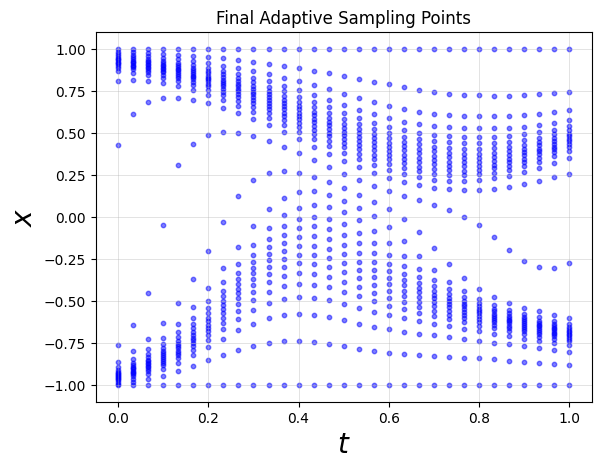

In [8]:
# 替换原来的训练cell
# 运行迭代训练
trained_model, final_collocation_pts = iterative_training_with_adaptive_sampling_1d(
    initial_epochs=pinn_initial_epochs,
    adaptive_epochs=pinn_adaptive_epochs,
    num_iterations=num_iterations,
    mmpde_training_epochs=mmpde_training_epochs
)

print("训练完成！")

# 可视化最终采样点
t_colloc_final = final_collocation_pts[:, 0:1]
x_colloc_final = final_collocation_pts[:, 1:2]

plt.scatter(t_colloc_final.detach().numpy(), x_colloc_final.detach().numpy(), 
           color='blue', alpha=0.5, s=10)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.title('Final Adaptive Sampling Points')
plt.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
plt.show()

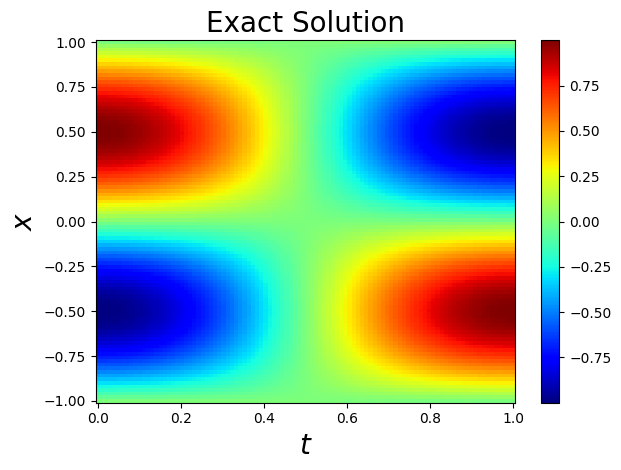

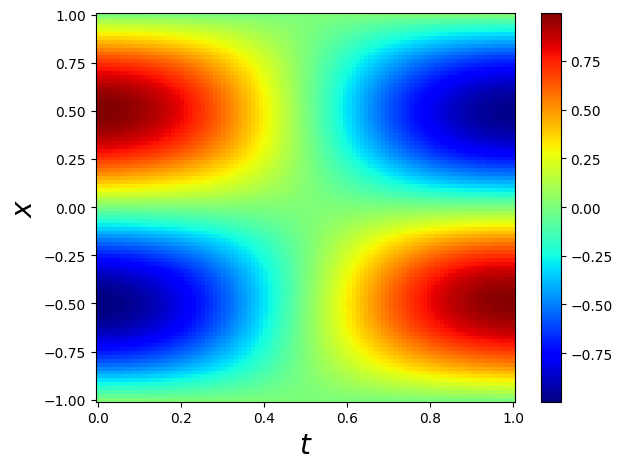

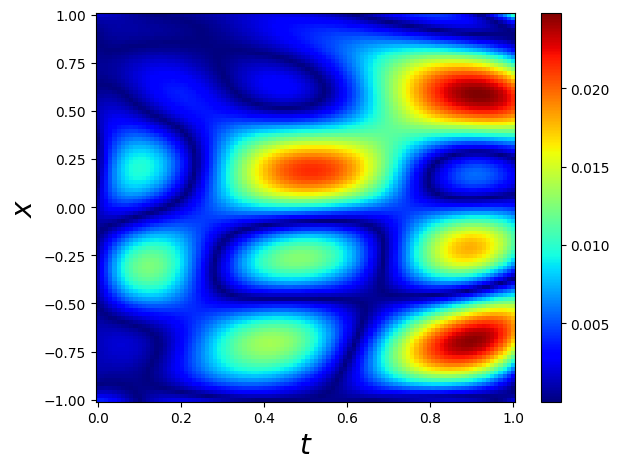

总体u的L2误差 (MMPDE): 0.008911


In [10]:
# 创建网格点进行测试和可视化
nx, nt = 100, 100
x = torch.linspace(-1, 1, nx).reshape(-1, 1)
t = torch.linspace(0, 1, nt).reshape(-1, 1)

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

# 组合输入
X_test = torch.cat([T_flat, X_flat], dim=1)

# 模型预测
with torch.no_grad():
    uv_pred = trained_model(X_test)

u_pred = uv_pred[:, 0].reshape(nx, nt).detach().numpy()
v_pred = uv_pred[:, 1].reshape(nx, nt).detach().numpy()

# 解析解
uv_exact = analytical_solution(T_flat, X_flat)
u_exact = uv_exact[:, 0].reshape(nx, nt).detach().numpy()
v_exact = uv_exact[:, 1].reshape(nx, nt).detach().numpy()

# 计算误差
u_error = np.abs(u_pred - u_exact)
v_error = np.abs(v_pred - v_exact)

# 分别显示精确结果图
plt.figure()
im = plt.pcolormesh(T.numpy(), X.numpy(), u_exact, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.title('Exact Solution', fontsize=20)
plt.tight_layout()
plt.show()

# 分别显示预测结果图
plt.figure()
im = plt.pcolormesh(T.numpy(), X.numpy(), u_pred, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.tight_layout()
plt.show()

# 分别显示误差图
plt.figure()
im = plt.pcolormesh(T.numpy(), X.numpy(), u_error, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.tight_layout()
plt.show()

# 计算L2误差
total_u_l2_error = np.sqrt(np.mean(np.square(u_pred - u_exact)))
print(f"总体u的L2误差 (MMPDE): {total_u_l2_error:.6f}")
